# Saccade‑aligned LFP average pipeline

**Environment:** Use the `eye_repo` conda environment.

This pipeline loads the exported `all_saccade_collection`, infers the required (animal, block) set, instantiates only those BlockSync blocks, filters to **synchronized (binocular) saccades only**, and computes **averaged LFP traces** aligned to saccade onset (t = 0), with **one average trace per animal** (no mixing across animals).

**Prerequisites:**
- Run `saccade_collection_pipeline.ipynb` and export `all_saccade_collection` to the configured `export_dir`.
- Electrophysiology (OE) data available for each block (`oe_rec` on BlockSync).

In [2]:
# =============================================================================
# IMPORTS
# =============================================================================
from __future__ import annotations
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from eye_tracking_system_tools.preprocessing import BlockSync
from eye_tracking_system_tools.preprocessing import utility_functions as uf

## Config

- `experiment_path`: parent of animal folders (same as saccade pipeline).
- `collection_path`: path to exported `all_saccade_collection.csv` (or use `export_dir` / `export_filename` from saccade pipeline).
- `lfp_channels`: list of OE channel numbers for LFP (e.g. `[1]`).
- `window_ms`: total window around saccade onset (ms). We use **± half_window**, so 100 ms → -50 to +50 ms.

In [9]:
experiment_path = Path(r"D:\sample_data_for_eye_repo")
export_dir = experiment_path / "analysis" / "saccade_collections"
export_filename = "all_saccade_collection.csv"
collection_path = export_dir / export_filename

lfp_channels = [1]   # OE channel numbers for LFP
window_ms = 200.0    # total window around onset (ms); we use ± window_ms/2
half_window_ms = window_ms / 2

## Load `all_saccade_collection` and infer required (animal, block) set

Load the exported collection, then derive unique `(animal, block)` pairs to instantiate only those BlockSync blocks.

In [4]:
all_saccade_collection = pd.read_csv(collection_path)
required = ["animal", "block", "Main", "Sub", "saccade_on_ms"]
missing = [c for c in required if c not in all_saccade_collection.columns]
if missing:
    raise ValueError(f"all_saccade_collection missing columns: {missing}")
print(f"Loaded {len(all_saccade_collection):,} rows from {collection_path.name}")

ab = all_saccade_collection[["animal", "block"]].drop_duplicates()
animals = ab["animal"].dropna().unique().astype(str).tolist()
block_lists = [
    [int(b) for b in ab.loc[ab["animal"] == a, "block"].dropna().unique().astype(str).tolist()]
    for a in animals
]
print(f"Inferred animals: {animals}; block_lists: {block_lists}")

Loaded 669 rows from all_saccade_collection.csv
Inferred animals: ['PV_106']; block_lists: [[15]]


## Build `block_collection` and `block_dict` for inferred (animal, block) only

Reuse the same helpers as the saccade pipeline. We only need BlockSync instances with `oe_rec`; no need to load `final_sync_df` or eye data for LFP extraction.

In [5]:
def create_block_collections(animals, block_lists, experiment_path, bad_blocks=None, regev=True):
    """Build block_collection and block_dict from animals and block lists."""
    if bad_blocks is None:
        bad_blocks = []
    block_collection = []
    block_dict = {}
    for animal, blocks in zip(animals, block_lists):
        current = uf.block_generator(
            block_numbers=blocks,
            experiment_path=experiment_path,
            animal=animal,
            bad_blocks=bad_blocks,
            regev=regev,
        )
        block_collection.extend(current)
        for b in current:
            block_dict[f"{animal}_block_{b.block_num}"] = b
    return block_collection, block_dict

block_collection, block_dict = create_block_collections(
    animals=animals,
    block_lists=block_lists,
    experiment_path=experiment_path,
    bad_blocks=[],
    regev=True,
)
print(f"Blocks: {list(block_dict.keys())}")

instantiated block number 015 at Path: D:\sample_data_for_eye_repo\PV_106\2025_09_04\block_015, new OE version
Found the sample rate for block 015 in the xml file, it is 20000 Hz

Extracting meta data from: D:\sample_data_for_eye_repo\PV_106\2025_09_04\block_015\oe_files\PV106_IMU_trial4_prey_2025-09-04_13-24-17\Record Node 106...
Analog channel numbers contain duplicates!!! Reordering numbers serially.

Extracting time stamp information...

Error!!! Some blocks are missing in recording!!!

Checking integrity of all records in ch1...

Metadata extraction complete.
created the .oe_rec attribute as an open ephys recording obj with get_data functionality (standalone mode, no metadata file)
retrieving zertoh sample number for block 015
got it!
Blocks: ['PV_106_block_015']


## Filter to synchronized saccades only, one row per pair

Keep only synced (binocular) events. Use one row per pair (e.g. L) so each saccade is counted once. `saccade_on_ms` is in ms (from `ms_axis`).

In [6]:
synced = all_saccade_collection.dropna(subset=["Main"]).copy()
synced_one_per_pair = synced.query('Sub == "L"').copy()
print(f"Synced saccades (one per pair): {len(synced_one_per_pair)}")
synced_one_per_pair.head()

Synced saccades (one per pair): 226


,Main,Sub,saccade_start_ind,saccade_end_ind,saccade_start_timestamp,saccade_end_timestamp,saccade_on_ms,saccade_off_ms,length,magnitude_raw,...,initial_x,initial_y,end_x,end_y,calib_dx,calib_dy,speed_profile,animal,block,eye
0,0.0,L,1103,1107,1185224.0,1186556.0,59261.20,59327.80,4,38.045673,...,273.486470,240.891843,272.964242,229.347818,-0.522228,-11.544025,[ nan 18.15984801 12.73739529 5.799417...,PV_106,15,L
1,1.0,L,1133,1136,1195214.0,1196213.0,59760.70,59810.65,3,10.652197,...,270.868028,229.577565,266.925660,238.489003,-3.942368,8.911438,[0.63009723 3.72089096 5.30451075 0.99669763],PV_106,15,L
2,2.0,L,1168,1171,1206869.0,1207868.0,60343.45,60393.40,3,5.766493,...,271.272991,233.466588,268.036610,237.683190,-3.236381,4.216602,[0.4192718 2.23897981 2.10736473 1.00087641],PV_106,15,L
3,3.0,L,1274,1276,1242167.0,1242833.0,62108.35,62141.65,2,7.739014,...,270.229955,237.399945,277.103910,237.792368,6.873955,0.392423,[0.83043308 5.24173777 1.66684266],PV_106,15,L
4,4.0,L,1279,1281,1243832.0,1244498.0,62191.60,62224.90,2,4.261767,...,278.312070,238.695116,274.887677,239.564361,-3.424393,0.869245,[0.54744132 2.12841179 1.58591369],PV_106,15,L


## Extract LFP windows and average per animal

For each synced saccade we fetch `window_ms` of LFP centered on saccade onset (onset → 0). We use **`saccade_on_ms`** from the collection (same timebase as block sync). `start = saccade_on_ms - half_window_ms`. We skip windows outside `[0, recordingDuration_ms)`. We **do not mix** traces across animals: one average trace per animal.

*Time alignment:* `saccade_on_ms` is assumed to match the OE recording timebase. If LFP traces look misaligned, verify sync pipeline output (e.g. `ms_axis` vs OE) and adjust.

In [22]:
window_ms = 2000
half_window_ms = window_ms / 2
def _block_key(animal, block):
    b = str(block).strip()
    if len(b) < 3:
        b = b.zfill(3)
    return f"{animal}_block_{b}"

mean_lfp_per_animal = {}
for animal in animals:
    rows = synced_one_per_pair[synced_one_per_pair["animal"] == animal]
    if rows.empty:
        continue
    windows = []
    for _, r in rows.iterrows():
        key = _block_key(r["animal"], r["block"])
        block = block_dict.get(key)
        if block is None or not hasattr(block, "oe_rec") or block.oe_rec is None:
            continue
        onset_ms = float(r["saccade_on_ms"])
        start_ms = onset_ms - half_window_ms
        dur_ms = getattr(block.oe_rec, "recordingDuration_ms", None)
        if dur_ms is not None:
            dur_ms = float(dur_ms) if not hasattr(dur_ms, "item") else float(dur_ms.item())
        if dur_ms is not None and (start_ms < 0 or start_ms + window_ms > dur_ms):
            continue
        try:
            start_arr = np.atleast_2d(np.asarray([start_ms], dtype=float))
            data, ts = block.oe_rec.get_data(
                lfp_channels,
                start_arr,
                window_ms,
                convert_microvolts=True,
                return_timestamps=True,
                repress_output=True,
            )
        except Exception:
            continue
        if data is None or data.size == 0:
            continue
        win = data[0, 0, :]
        windows.append(win)
    if not windows:
        continue
    stack = np.stack(windows)
    mean_lfp = np.nanmean(stack, axis=0)
    n_samp = mean_lfp.size
    t_rel_ms = np.linspace(-half_window_ms, half_window_ms, n_samp, endpoint=True)
    mean_lfp_per_animal[animal] = (t_rel_ms, mean_lfp)
    print(f"{animal}: n={len(windows)} windows, mean trace length {n_samp}")

PV_106: n=226 windows, mean trace length 40000


## Plot averaged LFP per animal (aligned to saccade onset = 0)

Time axis: ms relative to saccade onset. One mean trace per animal; **no mixing** across animals.

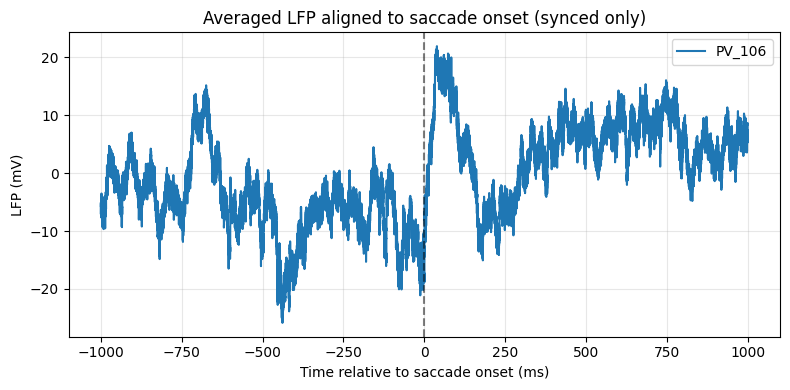

In [23]:
fig, ax = plt.subplots(figsize=(8, 4))
for animal, (t_rel, lfp) in mean_lfp_per_animal.items():
    ax.plot(t_rel, lfp, label=animal)
ax.axvline(0, color="k", ls="--", alpha=0.5)
ax.set_xlabel("Time relative to saccade onset (ms)")
ax.set_ylabel("LFP (mV)")
ax.set_title("Averaged LFP aligned to saccade onset (synced only)")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()